# Lab 003 — Simple Sequential Workflow

## Learning Objectives

By the end of this lab, you will:

- Build a workflow with multiple nodes
- Understand how state moves through a graph
- Learn how nodes execute in sequence
- Observe state transformations at each step

---

## Concept Overview

A sequential workflow executes nodes one after another.

Each node receives the current state, performs some work, and returns an updated state.

```text
START
   |
   v
node_a
   |
   v
node_b
   |
   v
node_c
   |
   v
END
```

The output of one node becomes the input of the next node.

---

## Step 1 — Imports


In [3]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph
from langgraph.graph import START, END


---

## Step 2 — Define State


In [4]:
class State(TypedDict):
    message: str



Our workflow will progressively build a message.

---

## Step 3 — Create the Nodes

### Node A


In [5]:
def node_a(state: State):
    return {
        "message": state["message"] + " A"
    }


### Node B

In [6]:
def node_b(state: State):
    return {
        "message": state["message"] + " B"
    }

### Node C

In [7]:
def node_c(state: State):
    return {
        "message": state["message"] + " C"
    }


Each node appends text to the existing message.

---

## Step 4 — Build the Graph


In [8]:
builder = StateGraph(State)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", END)

---

## Step 5 — Compile the Graph

In [9]:
graph = builder.compile()


---

## Step 6 — Visualize the Graph


Expected structure:

```text
START
   |
node_a
   |
node_b
   |
node_c
   |
  END
```


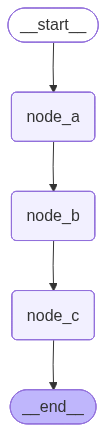

In [10]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

---

## Step 7 — Execute the Graph

In [11]:
result = graph.invoke(
    {
        "message": "Start"
    }
)


---

## Expected Output

```python
{
    "message": "Start A B C"
}
```

---

## Understanding State Flow

### Initial State

```python
{
    "message": "Start"
}
```

### After node_a

```python
{
    "message": "Start A"
}
```

### After node_b

```python
{
    "message": "Start A B"
}
```

### After node_c

```python
{
    "message": "Start A B C"
}
```

### Final State

```python
{
    "message": "Start A B C"
}
```

---

## Streaming Execution

Instead of waiting for the final result, we can observe execution step-by-step.

```python
for step in graph.stream(
    {
        "message": "Start"
    }
):
    print(step)
```

Example output:

```python
{'node_a': {'message': 'Start A'}}
{'node_b': {'message': 'Start A B'}}
{'node_c': {'message': 'Start A B C'}}
```

---

## Experiment

Add a fourth node.

```text
START
   |
node_a
   |
node_b
   |
node_c
   |
node_d
   |
 END
```

Example:

```python
def node_d(state: State):
    return {
        "message": state["message"] + " D"
    }
```

---

## Lab Challenge

Create a workflow that builds a sentence.

Example:

```text
START
   |
greeting
   |
subject
   |
ending
   |
 END
```

Expected output:

```python
{
    "message": "Hello LangGraph!"
}
```

---

## Key Takeaways

- Sequential workflows execute nodes one after another.
- State flows through the graph from node to node.
- Each node can update the state.
- The output of one node becomes the input of the next node.
- Streaming allows you to observe execution as it happens.
